In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import sys
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
plt.style.use('ggplot')
plt.tight_layout()

url = '/content/drive/MyDrive/Colab Notebooks/listings 2.csv'

df = pd.read_csv(url)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34049 entries, 0 to 34048
Data columns (total 75 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            34049 non-null  int64  
 1   listing_url                                   34049 non-null  object 
 2   scrape_id                                     34049 non-null  int64  
 3   last_scraped                                  34049 non-null  object 
 4   source                                        34049 non-null  object 
 5   name                                          34049 non-null  object 
 6   description                                   32760 non-null  object 
 7   neighborhood_overview                         18237 non-null  object 
 8   picture_url                                   34049 non-null  object 
 9   host_id                                       34049 non-null 

<Figure size 640x480 with 0 Axes>

In [7]:
# creating a new dataframe with necessary columns

cols = [
    'id',
    'name',
    'host_id',
    'host_name',
    'neighbourhood_cleansed',
    'neighbourhood_group_cleansed',
    'latitude',
    'longitude',
    'room_type',
    'property_type',
    'price',
    'minimum_nights',
    'number_of_reviews',
    'last_review',
    'reviews_per_month',
    'bedrooms',
    'bathrooms',
    'beds',
    'review_scores_rating',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value',
    'calculated_host_listings_count',
    'availability_30',
    'availability_60',
    'availability_90',
    'availability_365'
]

# update dataframe
df_data = df[cols]
df_data.info()

#update neighbourhood _groups_cleansed column to Island_Name

df_data.rename(columns={'neighbourhood_group_cleansed': 'island_name'}, inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34049 entries, 0 to 34048
Data columns (total 30 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              34049 non-null  int64  
 1   name                            34049 non-null  object 
 2   host_id                         34049 non-null  int64  
 3   host_name                       34047 non-null  object 
 4   neighbourhood_cleansed          34049 non-null  object 
 5   neighbourhood_group_cleansed    34049 non-null  object 
 6   latitude                        34049 non-null  float64
 7   longitude                       34049 non-null  float64
 8   room_type                       34049 non-null  object 
 9   property_type                   34049 non-null  object 
 10  price                           30985 non-null  object 
 11  minimum_nights                  34049 non-null  int64  
 12  number_of_reviews               

In [8]:
# check the count, mean, std, min, max, 25%, 50%, and 75% percentile of each attribute

df_data.describe()

,id,host_id,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,bedrooms,bathrooms,beds,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,availability_30,availability_60,availability_90,availability_365
count,3.404900e+04,3.404900e+04,34049.000000,34049.00000,34049.000000,34049.000000,26138.000000,33624.000000,31062.000000,31031.000000,...,26099.000000,26096.000000,26099.000000,26097.000000,26096.000000,34049.000000,34049.000000,34049.000000,34049.000000,34049.000000
mean,3.975108e+17,1.738481e+08,20.899669,-157.20165,8.395019,35.116479,1.180837,1.597192,1.637354,2.515162,...,4.769194,4.850776,4.837705,4.868135,4.680748,79.590972,11.323328,26.907457,43.716556,199.803607
std,4.321887e+17,1.678216e+08,0.817134,1.28524,27.251315,67.414209,1.363342,1.141094,0.921105,1.558636,...,0.323955,0.289730,0.312656,0.222996,0.368446,116.458935,10.175425,20.090403,29.168332,117.735989
min,5.269000e+03,9.080000e+02,18.920250,-159.71462,1.000000,0.000000,0.010000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,3.349427e+07,3.752000e+07,20.685630,-157.83944,1.000000,1.000000,0.250000,1.000000,1.000000,1.000000,...,4.680000,4.830000,4.800000,4.830000,4.580000,2.000000,2.000000,9.000000,19.000000,92.000000
50%,5.341957e+07,1.101274e+08,20.960189,-156.69104,2.000000,8.000000,0.700000,1.000000,1.000000,2.000000,...,4.860000,4.940000,4.940000,4.930000,4.760000,19.000000,9.000000,25.000000,44.000000,223.000000
75%,8.150737e+17,3.033865e+08,21.311710,-156.31989,4.000000,39.000000,1.740000,2.000000,2.000000,3.000000,...,5.000000,5.000000,5.000000,5.000000,4.900000,110.000000,19.000000,44.000000,68.000000,302.000000
max,1.117529e+18,5.677585e+08,22.229090,-154.84100,1000.000000,1285.000000,52.210000,24.000000,14.000000,32.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,488.000000,30.000000,60.000000,90.000000,365.000000


In [9]:
pd.options.display.float_format = '{:.2f}'.format  # Set global display format
print(df_data)

                       id                                               name  \
0                34421962                         Waipouli Beach Resort E106   
1                40707945           DO NOT PUBLISH BEFORE MERGING 14891-HROV   
2                43656551    Ilikai 1212 Ocean / Lagoon / King Bed, Sofa Bed   
3                39096262                                $900 rooms for rent   
4      735005738415289686  The Point at Poipu, a Hilton Vacation Club, Kauai   
...                   ...                                                ...   
34044  755988499595645037          Kona Coast Resort 1 Bedroom, full kitchen   
34045  756678668207738929                     Stunning *Paniolo Greens* 2B#3   
34046  969798240699256199                    Thanksgiving in Kauai - 2bd/2ba   
34047  887965228349983780      Beautiful & Relaxing Holua Resort - 2 Bedroom   
34048  891631866049506737                       One Bedroom Guest Suite Kona   

         host_id                  host_

Number of rows with NaN values in 'price': 3064


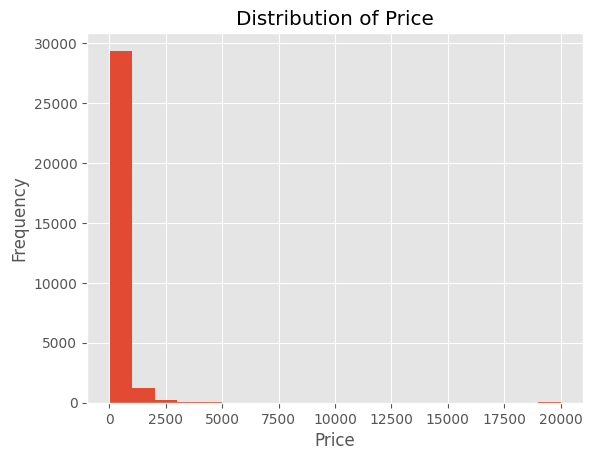

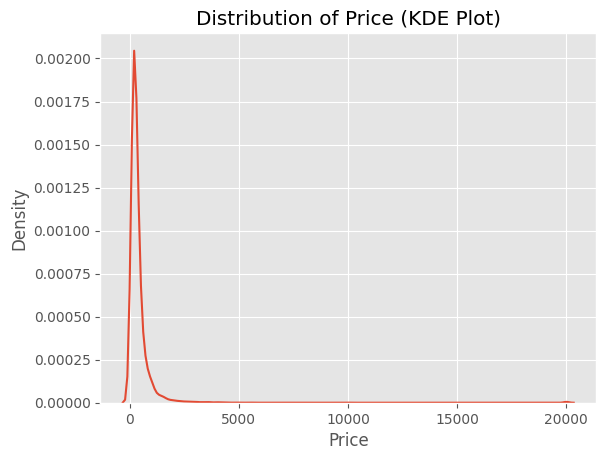

Interpretation of KDE Plot:
--------------------------------------------
• The KDE plot shows the distribution of prices for Airbnb listings.
• The peak of the curve represents the most common price range.
• The spread of the curve indicates the price variability.
• The tail of the curve shows the presence of some listings with higher prices.


Descriptive Statistics:
--------------------------------------------
count   30985.00
mean      409.80
std       889.39
min        20.00
25%       167.00
50%       254.00
75%       418.00
max     20000.00
Name: price, dtype: float64
Interpretation of Descriptive Statistics:
--------------------------------------------
• Count: The total number of listings considered.
• Mean: The average price of listings.
• Std: The standard deviation, indicating price variability.
• Min: The minimum price of a listing.
• 25%: The first quartile (25th percentile).
• 50%: The median price (50th percentile).
• 75%: The third quartile (75th percentile).
• Max: The 

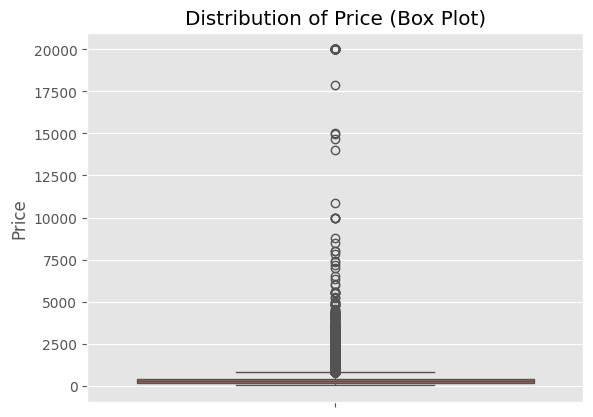

Interpretation of Box Plot with Outliers:
--------------------------------------------
• Presence of Outliers: The box plot shows many data points above the upper whisker, indicating the presence of numerous outliers in the price variable.
• Skewed Distribution: The presence of outliers primarily above the upper whisker suggests that the price distribution is right-skewed (positively skewed).
   This implies there are a few listings with  unusually high prices  compared to the majority of listings.
• Impact on Analysis: Outliers can significantly influence statistical measures like the mean and standard deviation.
   In this case, the outliers are likely pulling the mean price upwards.


In [10]:
nan_count = df_data['price'].isna().sum()
print(f"Number of rows with NaN values in 'price': {nan_count}")

# convert formatting for price

df_data['price'] = df_data['price'].astype(str).str.replace('[\$,]', '', regex=True).astype(float)

# Now create the histogram
plt.hist(df_data['price'], bins=20)  # Adjust the number of bins as needed
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribution of Price')
plt.show()

# KDE Plot
sns.kdeplot(df_data['price'])
plt.xlabel('Price')
plt.ylabel('Density')
plt.title('Distribution of Price (KDE Plot)')
plt.show()

print('\033[34m' + 'Interpretation of KDE Plot:' + '\033[0m')
print('--------------------------------------------')
kde_explanation = [
    "• The KDE plot shows the \033[1m" + "distribution of prices" + "\033[0m" +  '\033[34m' + " for Airbnb listings." + '\033[0m',
    "• The \033[1m" + "peak of the curve" + "\033[0m" + '\033[34m' + " represents the most common price range." + '\033[0m',
    "• The \033[1m" + "spread of the curve" + "\033[0m" + '\033[34m' + " indicates the price variability." + '\033[0m',
    "• The \033[1m" + "tail of the curve" + "\033[0m" + '\033[34m' + " shows the presence of some listings with higher prices." + '\033[0m'
]
for line in kde_explanation:
    print(line)
print("\n")  # Add an extra line for spacing


# Descriptive Statistics
print('\033[1m' + '\033[34m' + 'Descriptive Statistics:' + '\033[0m')  # Bold and blue heading
print('--------------------------------------------')

print(df_data['price'].describe()) #Display results

print('\033[34m' + 'Interpretation of Descriptive Statistics:' + '\033[0m')
print('--------------------------------------------')
desc_explanation = [
    "• \033[1m" + "Count:" + "\033[0m" + '\033[34m' + " The total number of listings considered." + '\033[0m',
    "• \033[1m" + "Mean:" + "\033[0m" + '\033[34m' + " The average price of listings." + '\033[0m',
    "• \033[1m" + "Std:" + "\033[0m" + '\033[34m' + " The standard deviation, indicating price variability." + '\033[0m',
    "• \033[1m" + "Min:" + "\033[0m" + '\033[34m' + " The minimum price of a listing." + '\033[0m',
    "• \033[1m" + "25%:" + "\033[0m" + '\033[34m' + " The first quartile (25th percentile)." + '\033[0m',
    "• \033[1m" + "50%:" + "\033[0m" + '\033[34m' + " The median price (50th percentile)." + '\033[0m',
    "• \033[1m" + "75%:" + "\033[0m" + '\033[34m' + " The third quartile (75th percentile)." + '\033[0m',
    "• \033[1m" + "Max:" + "\033[0m" + '\033[34m' + " The maximum price of a listing." + '\033[0m'
]
for line in desc_explanation:
    print(line)
print("\n")  # Add an extra line for spacing


# Box Plot
sns.boxplot(y=df_data['price'])
plt.ylabel('Price')
plt.title('Distribution of Price (Box Plot)')
plt.show()

print('\033[34m' + 'Interpretation of Box Plot with Outliers:' + '\033[0m')
print('--------------------------------------------')
box_explanation = [

    "• \033[1m" + "Presence of Outliers:" + "\033[0m" + '\033[34m' + " The box plot shows many data points \033[1m" + "above" + "\033[0m" + '\033[34m' " the upper whisker, indicating the presence of numerous outliers in the price variable." + '\033[0m',
    # Wrap the second bullet point using textwrap.fill
    "• \033[1m" + "Skewed Distribution:" + "\033[0m" + '\033[34m' + " The presence of outliers primarily \033[1m" + "above" + "\033[0m" + '\033[34m' " the upper whisker suggests that the price distribution is \033[1m" + "right-skewed" + '\033[34m' +" (positively skewed)."
    + '\033[0m'
    + "\n"  # Add a newline character for the second line
    + "   "  # Add indentation for the second line
    + '\033[34m' + "This implies there are a few listings with \033[1m unusually high prices \033[0m \033[34mcompared to the majority of listings." + '\033[0m',
    "• \033[1m" + "Impact on Analysis:" + "\033[0m" + '\033[34m' + " Outliers can significantly influence statistical measures like the \033[1m" + "mean" + "\033[0m" '\033[34m' + " and \033[1m" + "standard deviation." + "\033[0m"  + '\033[34m'
    + "\n"  # Add a newline character for the second line
    + "   "  # Add indentation for the second line
    + "In this case, the outliers are likely pulling the mean price upwards." + '\033[0m'

]

for line in box_explanation:
    print(line)

# Missing Values (NaN) for ratings columns

In [11]:
from math import nan
nan_count0 = df_data['review_scores_rating'].isna().sum()
print(f"Number of rows with NaN values in 'review_scores_rating': {nan_count0}")

nan_count1 = df_data['review_scores_communication'].isna().sum()
print(f"Number of rows with NaN values in 'review_scores_communication': {nan_count1}")

nan_count2 = df_data['review_scores_location'].isna().sum()
print(f"Number of rows with NaN values in 'review_scores_location': {nan_count2}")

nan_count3 = df_data['review_scores_accuracy'].isna().sum()
print(f"Number of rows with NaN values in 'review_scores_accuracy': {nan_count3}")

nan_count4 = df_data['review_scores_cleanliness'].isna().sum()
print(f"Number of rows with NaN values in 'review_scores_cleanliness': {nan_count4}")


nan_count5 = df_data['review_scores_checkin'].isna().sum()
print(f"Number of rows with NaN values in 'review_scores_checkin': {nan_count5}")


nan_count6 = df_data['review_scores_value'].isna().sum()
print(f"Number of rows with NaN values in 'review_scores_value': {nan_count6}")

import pandas as pd
import numpy as np
from tabulate import tabulate

# Define the rating score columns, with review_scores_rating as the first
rating_cols = ['review_scores_rating', 'review_scores_communication', 'review_scores_location', 'review_scores_accuracy',
               'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_value']

# Create an empty list to store the results
results = []

# Loop through each rating score column
for col in rating_cols:
    # Calculate missing values
    nan_count = df_data[col].isna().sum()

    # Calculate outliers using IQR
    Q1 = df_data[col].quantile(0.25)
    Q3 = df_data[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR
    outlier_count = df_data[(df_data[col] < lower_bound) | (df_data[col] > upper_bound)].shape[0]

   # Calculate percentage of outliers
    total_count = df_data[col].shape[0]  # Get the total number of non-NaN values
    outlier_percentage = (outlier_count / total_count) * 100 if total_count else 0  # Avoid division by zero

    # Append the results to the list
    results.append([col, nan_count, outlier_count, f"{outlier_percentage:.2f}%"])

# Create a DataFrame from the results
results_df = pd.DataFrame(results, columns=['Column', 'Missing Values', 'Outliers', '% Outliers'])

# Print the tabulated results
print(tabulate(results_df, headers='keys', tablefmt='pipe'))


Number of rows with NaN values in 'review_scores_rating': 7911
Number of rows with NaN values in 'review_scores_communication': 7950
Number of rows with NaN values in 'review_scores_location': 7952
Number of rows with NaN values in 'review_scores_accuracy': 7950
Number of rows with NaN values in 'review_scores_cleanliness': 7950
Number of rows with NaN values in 'review_scores_checkin': 7953
Number of rows with NaN values in 'review_scores_value': 7953
|    | Column                      |   Missing Values |   Outliers | % Outliers   |
|---:|:----------------------------|-----------------:|-----------:|:-------------|
|  0 | review_scores_rating        |             7911 |       1398 | 4.11%        |
|  1 | review_scores_communication |             7950 |       1759 | 5.17%        |
|  2 | review_scores_location      |             7952 |       1646 | 4.83%        |
|  3 | review_scores_accuracy      |             7950 |       1669 | 4.90%        |
|  4 | review_scores_cleanliness   |   

In [12]:
# Ratings columns has missing values, which can be addressed using imputation method.

import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler  # For normalization

# Define rating score columns and features for distance calculation

feature_cols = [
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'bedrooms',
    'bathrooms',
    'beds',
    'calculated_host_listings_count',
    'availability_30',
    'availability_60',
    'availability_90',
    'availability_365']
  # Add relevant features

# Normalize the features
scaler = StandardScaler()
df_data[feature_cols] = scaler.fit_transform(df_data[feature_cols])

# Create a KNN imputer object
imputer = KNNImputer(n_neighbors=5)

# Impute the missing values in the rating score columns
df_data[rating_cols] = imputer.fit_transform(df_data[rating_cols])
print(df_data[rating_cols].head())


   review_scores_rating  review_scores_communication  review_scores_location  \
0                  4.79                         4.84                    4.87   
1                  4.79                         4.84                    4.87   
2                  4.60                         4.63                    4.87   
3                  4.79                         4.84                    4.87   
4                  4.79                         4.84                    4.87   

   review_scores_accuracy  review_scores_cleanliness  review_scores_checkin  \
0                    4.80                       4.77                   4.85   
1                    4.80                       4.77                   4.85   
2                    4.67                       4.60                   4.79   
3                    4.80                       4.77                   4.85   
4                    4.80                       4.77                   4.85   

   review_scores_value  
0                 4

In [13]:
df_data = df_data.dropna(subset=['price'])

In [14]:
# check the heading of the dataset

df_data.head()

,id,name,host_id,host_name,neighbourhood_cleansed,island_name,latitude,longitude,room_type,property_type,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,availability_30,availability_60,availability_90,availability_365
0,34421962,Waipouli Beach Resort E106,34386367,Kauai Calls!,Kapaa-Wailua,Kauai,22.06,-159.32,Entire home/apt,Entire condo,...,4.77,4.85,4.84,4.87,4.68,-0.33,-0.23,-0.54,-0.71,0.37
1,40707945,DO NOT PUBLISH BEFORE MERGING 14891-HROV,182704096,Aston Waikiki Beach Hotel,Primary Urban Center,Honolulu,21.27,-157.82,Private room,Room in hotel,...,4.77,4.85,4.84,4.87,4.68,-0.61,1.84,1.65,1.59,1.40
2,43656551,"Ilikai 1212 Ocean / Lagoon / King Bed, Sofa Bed",347952914,Hawaii Vacation,Primary Urban Center,Honolulu,21.28,-157.84,Entire home/apt,Entire condo,...,4.60,4.79,4.63,4.87,4.54,-0.01,-0.82,-0.79,-0.98,-0.47
5,591360042819349915,Kauai Kailani 318,34386367,Kauai Calls!,Kapaa-Wailua,Kauai,22.06,-159.32,Entire home/apt,Entire condo,...,4.71,4.86,4.43,4.43,4.29,-0.33,-0.72,-0.59,-0.54,0.34
6,1101928073662975174,Great Location Lahaina shcool,130486117,Dayong,Lahaina,Maui,20.89,-156.67,Shared room,Shared room in home,...,4.77,4.85,4.84,4.87,4.68,-0.67,-1.11,-1.34,-1.50,-1.59


In [15]:
num_rows = df_data.shape[0] #Provide the number of rows in the dataset
num_cols = df_data.shape[1] #Provide the number of columns in the dataset
print(num_rows)
print(num_cols)

30985
30


In [16]:
# check the missing values in the dataset

df_data.isnull().sum()

,0
id,0
name,0
host_id,0
host_name,2
neighbourhood_cleansed,0
island_name,0
latitude,0
longitude,0
room_type,0
property_type,0


{'host_id', 'island_name', 'review_scores_accuracy', 'latitude', 'property_type', 'name', 'availability_90', 'price', 'calculated_host_listings_count', 'review_scores_location', 'review_scores_communication', 'number_of_reviews', 'room_type', 'review_scores_value', 'availability_30', 'neighbourhood_cleansed', 'longitude', 'review_scores_cleanliness', 'id', 'availability_365', 'review_scores_checkin', 'minimum_nights', 'review_scores_rating', 'availability_60'}


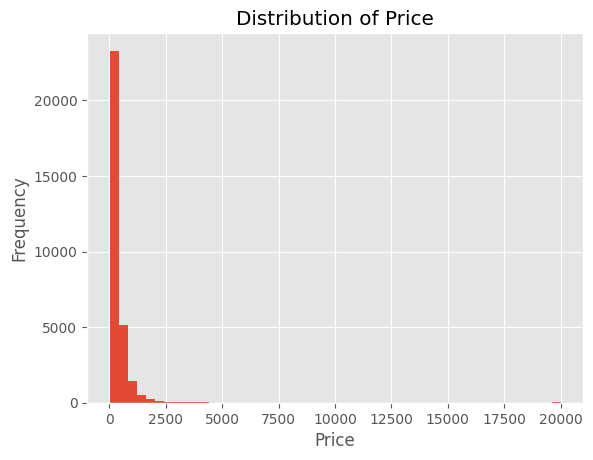

In [17]:
# obtain a set of columns with 0 missing values

no_nulls = set(df_data.columns[df_data.isnull().mean()==0])
print(no_nulls)

import matplotlib.pyplot as plt

plt.hist(df_data['price'], bins=50)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribution of Price')
plt.show()

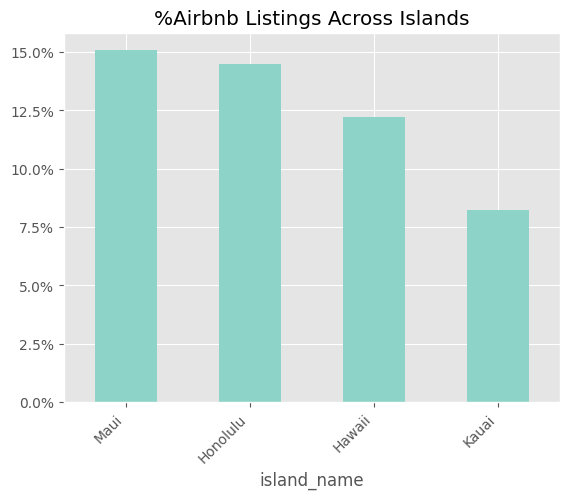

In [18]:
# obtain a bar chart of the proportion of Airbnb listings in four neighbourhood groups
import matplotlib.ticker as mtick

(df_data.island_name.value_counts()/df_data.shape[0]).plot.bar(cmap='Set3',title='%Airbnb Listings Across Islands')
plt.xticks(rotation=45, ha='right')

# Formatting Y-axis to display percentage labels
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(2.0))

plt.show()

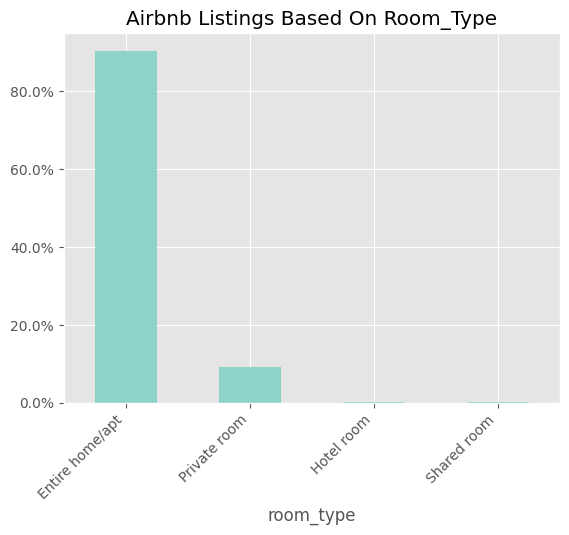

In [19]:

# obtain a bar chart of the proportion of Airbnb listings in room_type

#(df_data.room_type.value_counts()*100 /df_data.shape[0]).plot.bar(cmap='Pastel1',title='Airbnb Listings Based On Room_Type')


import matplotlib.ticker as mtick

(df_data.room_type.value_counts()/df_data.shape[0]).plot.bar(cmap='Set3',title='Airbnb Listings Based On Room_Type')
plt.xticks(rotation=45, ha='right')

# Formatting Y-axis to display percentage labels with 0.5% increments
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))

plt.show()

                 price                               minimum_nights         \
                  mean median     std   min      max           mean median   
room_type                                                                    
Entire home/apt 383.49 257.00  497.52 20.00 17850.00          -0.03  -0.23   
Hotel room      536.10 292.00  684.22 96.00  3495.00          -0.25  -0.27   
Private room    671.42 217.50 2473.92 23.00 20000.00           0.04  -0.23   
Shared room     160.51  60.00  369.47 30.00  1995.00           0.16  -0.27   

                                 number_of_reviews                          
                 std   min   max              mean median  std   min   max  
room_type                                                                   
Entire home/apt 0.90 -0.27 13.09              0.03  -0.37 0.99 -0.52 17.65  
Hotel room      0.05 -0.27 -0.05             -0.05  -0.48 1.03 -0.52  5.41  
Private room    0.93 -0.27  6.52              0.02  -0.49 1.38 -0.52

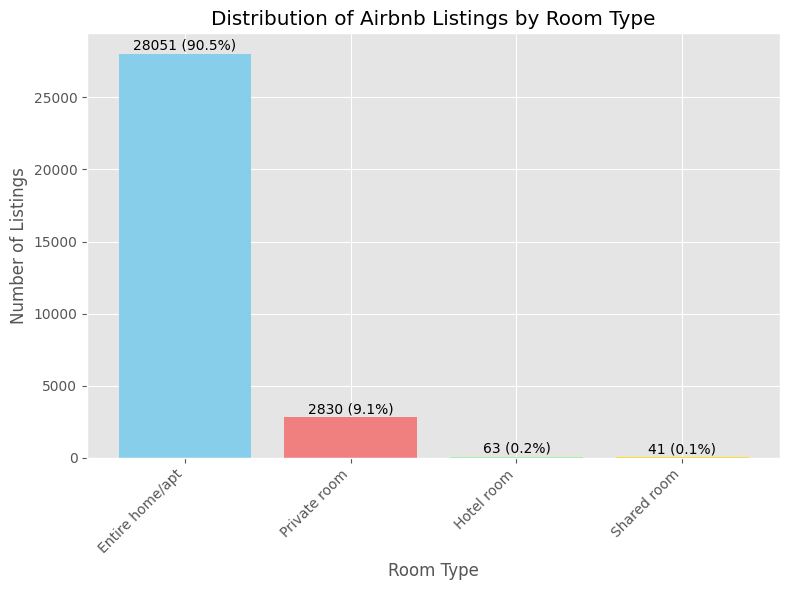

In [20]:
# Group data by room type and calculate statistics
room_type_stats = df_data.groupby('room_type').agg({
    'price': ['mean', 'median', 'std', 'min', 'max'],  # Statistics for price
    'minimum_nights': ['mean', 'median', 'std', 'min', 'max'],  # Statistics for minimum_nights
    'number_of_reviews': ['mean', 'median', 'std', 'min', 'max'],  # Statistics for number_of_reviews
    # Add other columns for which you want statistics
})

# Display the results
print(room_type_stats)

# Calculate the count of listings for each room type
room_type_counts = df_data['room_type'].value_counts()

# Calculate percentages
total_listings = df_data.shape[0]
room_type_percentages = (room_type_counts / total_listings) * 100

# Create a bar chart
plt.figure(figsize=(8, 6))  # Adjust figure size if needed
plt.bar(room_type_counts.index, room_type_counts.values, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
plt.title('Distribution of Airbnb Listings by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability

# Add labels to the bars (optional)
#for i, count in enumerate(room_type_counts.values):
    #plt.text(i, count + 50, str(count), ha='center', va='bottom')  # Adjust position as needed

for i, count in enumerate(room_type_counts.values):
    percentage = room_type_percentages[i]
    plt.text(i, count + 50, f"{count} ({percentage:.1f}%)", ha='center', va='bottom')

plt.tight_layout()
plt.show()




In [21]:
# convert formatting for price

df_data['price'] = df_data['price'].astype(str).str.replace('[\$,]', '', regex=True).astype(float)

In [22]:
# checking if the price format was convert correctly

df_data['price'].head()
df_data['price'].isna().sum()

nan_count = df_data['price'].isna().sum()
print(f"Number of rows with NaN values in 'price': {nan_count}")

Number of rows with NaN values in 'price': 0


In [23]:
!pip install tabulate

In [24]:
# obtain a dataframe of average price across the four neighbourhood groups in room_type

from tabulate import tabulate

# Calculate the average prices
result = df_data.groupby(['island_name', 'room_type', 'property_type'])['price'].mean().reset_index()

# Rename the 'price' column to 'Average Price'
result = result.rename(columns={'price': 'Average Price'})

# Format 'Average Price' to two decimal places
result['Average Price'] = result['Average Price'].apply(lambda x: '{:.2f}'.format(x))

# Print the result
print(result)

    island_name        room_type               property_type Average Price
0        Hawaii  Entire home/apt                        Barn        160.00
1        Hawaii  Entire home/apt                   Camper/RV        115.25
2        Hawaii  Entire home/apt                    Campsite         57.00
3        Hawaii  Entire home/apt             Casa particular        443.00
4        Hawaii  Entire home/apt               Cycladic home         20.00
..          ...              ...                         ...           ...
211        Maui      Shared room                 Shared room         55.00
212        Maui      Shared room         Shared room in home         65.00
213        Maui      Shared room        Shared room in hotel       1395.00
214        Maui      Shared room  Shared room in rental unit       1995.00
215        Maui      Shared room         Shared room in tent         66.00

[216 rows x 4 columns]


In [25]:
unique_property_types = df_data['property_type'].unique()
print(unique_property_types)

df_data['property_type'] = df_data['property_type'].str.lower()  # Convert to lowercase

typo_corrections = {'aprtment': 'apartment', 'condoimum': 'condominium'}
df_data['property_type'] = df_data['property_type'].replace(typo_corrections)

#def group_property_types(property_type):
  #  if property_type in ['apartment', 'condo', 'loft']:
   #    return 'apartment/condo'
    #elif property_type in ['house', 'townhouse']:
    #    return 'house'
    #else:
     #   return 'other'

df_data['property_type_grouped'] = df_data['property_type'].apply
#(group_property_types)

import pandas as pd

def clean_property_type(property_type):
    property_type = property_type.lower()  # Standardize capitalization

    # Keywords to look for in property types
    keywords = [
        'condo', 'condominium', 'hotel', 'home', 'vacation home', 'rental unit', 'farm stay', 'tent', 'townhouse', 'cabin', 'bungalow', 'villa', 'bed and breakfast', 'Entire guesthouse' 'Entire cottage' 'Entire villa' 'Entire home/apt', 'Entire serviced apartment' 'Dome' 'Entire place' 'Entire guest suite', 'resort' 'Entire townhouse' 'Entire cabin'
        'nature lodge', 'serviced apartment', 'tower', 'resort', 'hut',
        'camper/rv', 'dome', 'minsu', 'casa particular', 'loft', 'chalet',
       'treehouse', 'castle', 'barn', 'island', 'yurt', 'earthen home', 'bed and breakfast', 'ranch', 'shipping container', 'hostel', 'aparthotel', 'campsite',
        'guest suite', 'place', 'guest house']
                # Add more keywords if needed

    # Extract the main property type
    for keyword in keywords:
        if keyword in property_type:
            return keyword

    return 'other'  # If no keyword is found

# Apply the cleaning function
df_data['property_type_cleaned'] = df_data['property_type'].apply(clean_property_type)

# Check the unique values in the cleaned column
print(df_data['property_type_cleaned'].unique())

df_data['property_type_cleaned'].nunique()

['Entire condo' 'Room in hotel' 'Shared room in home' 'Entire rental unit'
 'Private room in bed and breakfast' 'Entire home'
 'Private room in farm stay' 'Camper/RV' 'Room in boutique hotel'
 'Entire guesthouse' 'Entire cottage' 'Entire villa' 'Entire home/apt'
 'Entire serviced apartment' 'Dome' 'Entire place' 'Entire guest suite'
 'Private room in home' 'Private room in resort' 'Entire townhouse'
 'Entire cabin' 'Room in aparthotel' 'Campsite' 'Entire vacation home'
 'Private room in serviced apartment' 'Room in resort'
 'Private room in condo' 'Tent' 'Private room'
 'Private room in rental unit' 'Entire bungalow'
 'Private room in guest suite' 'Tiny home' 'Treehouse'
 'Private room in guesthouse' 'Private room in hostel'
 'Private room in nature lodge' 'Private room in cabin'
 'Private room in barn' 'Farm stay' 'Entire loft'
 'Private room in tiny home' 'Private room in townhouse'
 'Private room in bungalow' 'Shared room in rental unit'
 'Entire bed and breakfast' 'Barn' 'Shared ro

33

In [26]:
# Specify the file path and name
file_path = 'airbnb_data.csv'  # You can change the file name if needed

# Export to CSV
df_data.to_csv(file_path, index=False)

In [27]:
#print(df_data[['availability_30', 'availability_60','availability_90', 'availability_365']])

avg_availability = df_data.groupby(['island_name', 'room_type', 'property_type_cleaned'])[['availability_30', 'availability_60', 'availability_90', 'availability_365']].mean().reset_index()

#avg_availability = df_data.groupby(['island_name', 'room_type'])[['id', 'availability_30', 'availability_60', 'availability_90', 'availability_365']].agg({'id': 'first', 'availability_30': 'mean', 'availability_60': 'mean', 'availability_90': 'mean', 'availability_365': 'mean'}).reset_index()


# Rename the columns to 'Average availability_XX'
avg_availability = avg_availability.rename(columns={
    'availability_30': 'Avg_30',
    'availability_60': 'Avg_60',
    'availability_90': 'Avg_90',
    'availability_365': 'Avg_365'
})

# Format all 'Average availability_XX' columns to two decimal places
for col in ['Avg_30', 'Avg_60', 'Avg_90', 'Avg_365']:
    avg_availability[col] = avg_availability[col].apply(lambda x: '{:.2f}'.format(x))

#print(avg_availability)
print(tabulate(avg_availability, headers='keys', tablefmt='pipe'))

print("\n Average availability is not merged in the original dataframe to avoid \n the possibility of overfitting the prediction model.")

|     | island_name   | room_type       | property_type_cleaned   |   Avg_30 |   Avg_60 |   Avg_90 |   Avg_365 |
|----:|:--------------|:----------------|:------------------------|---------:|---------:|---------:|----------:|
|   0 | Hawaii        | Entire home/apt | barn                    |     0.66 |     0.7  |     0.87 |      1.02 |
|   1 | Hawaii        | Entire home/apt | bed and breakfast       |     0.26 |     0.5  |     0.8  |      0.97 |
|   2 | Hawaii        | Entire home/apt | bungalow                |     0.24 |     0.28 |     0.25 |      0.33 |
|   3 | Hawaii        | Entire home/apt | cabin                   |     0.36 |     0.41 |     0.49 |      0.51 |
|   4 | Hawaii        | Entire home/apt | camper/rv               |     1.59 |     1.29 |     1.3  |      0.53 |
|   5 | Hawaii        | Entire home/apt | campsite                |     0.46 |     0.6  |     0.87 |      1.22 |
|   6 | Hawaii        | Entire home/apt | casa particular         |     0.83 |     0.72 |     0.

In [28]:
# availability_365 = 0 suggests two things:
    # (1) when the listing has been removed
    # (2) when the room has been booked

# in order to remove condition (1) from the data:
    # select rows with 0 availability and
    # posts when they had at least one review in 2017

df_data['last_review'] = pd.to_datetime(df_data['last_review'])
df_data['review_year'] = df_data['last_review'].apply(lambda last_review:last_review.year)
df_data['review_year'] = df_data['review_year'].fillna(0)
df_data['review_year'] = df_data.review_year.astype(int)
df_data = pd.concat([df_data[(df_data['availability_365']==0) & (df_data['review_year']==2017)],df_data[df_data['availability_365']>0]])

In [29]:
(df_data['review_year'].unique()) #unique values for review year

array([   0, 2023, 2024, 2018, 2022, 2021, 2019, 2016, 2020, 2017, 2015,
       2014])

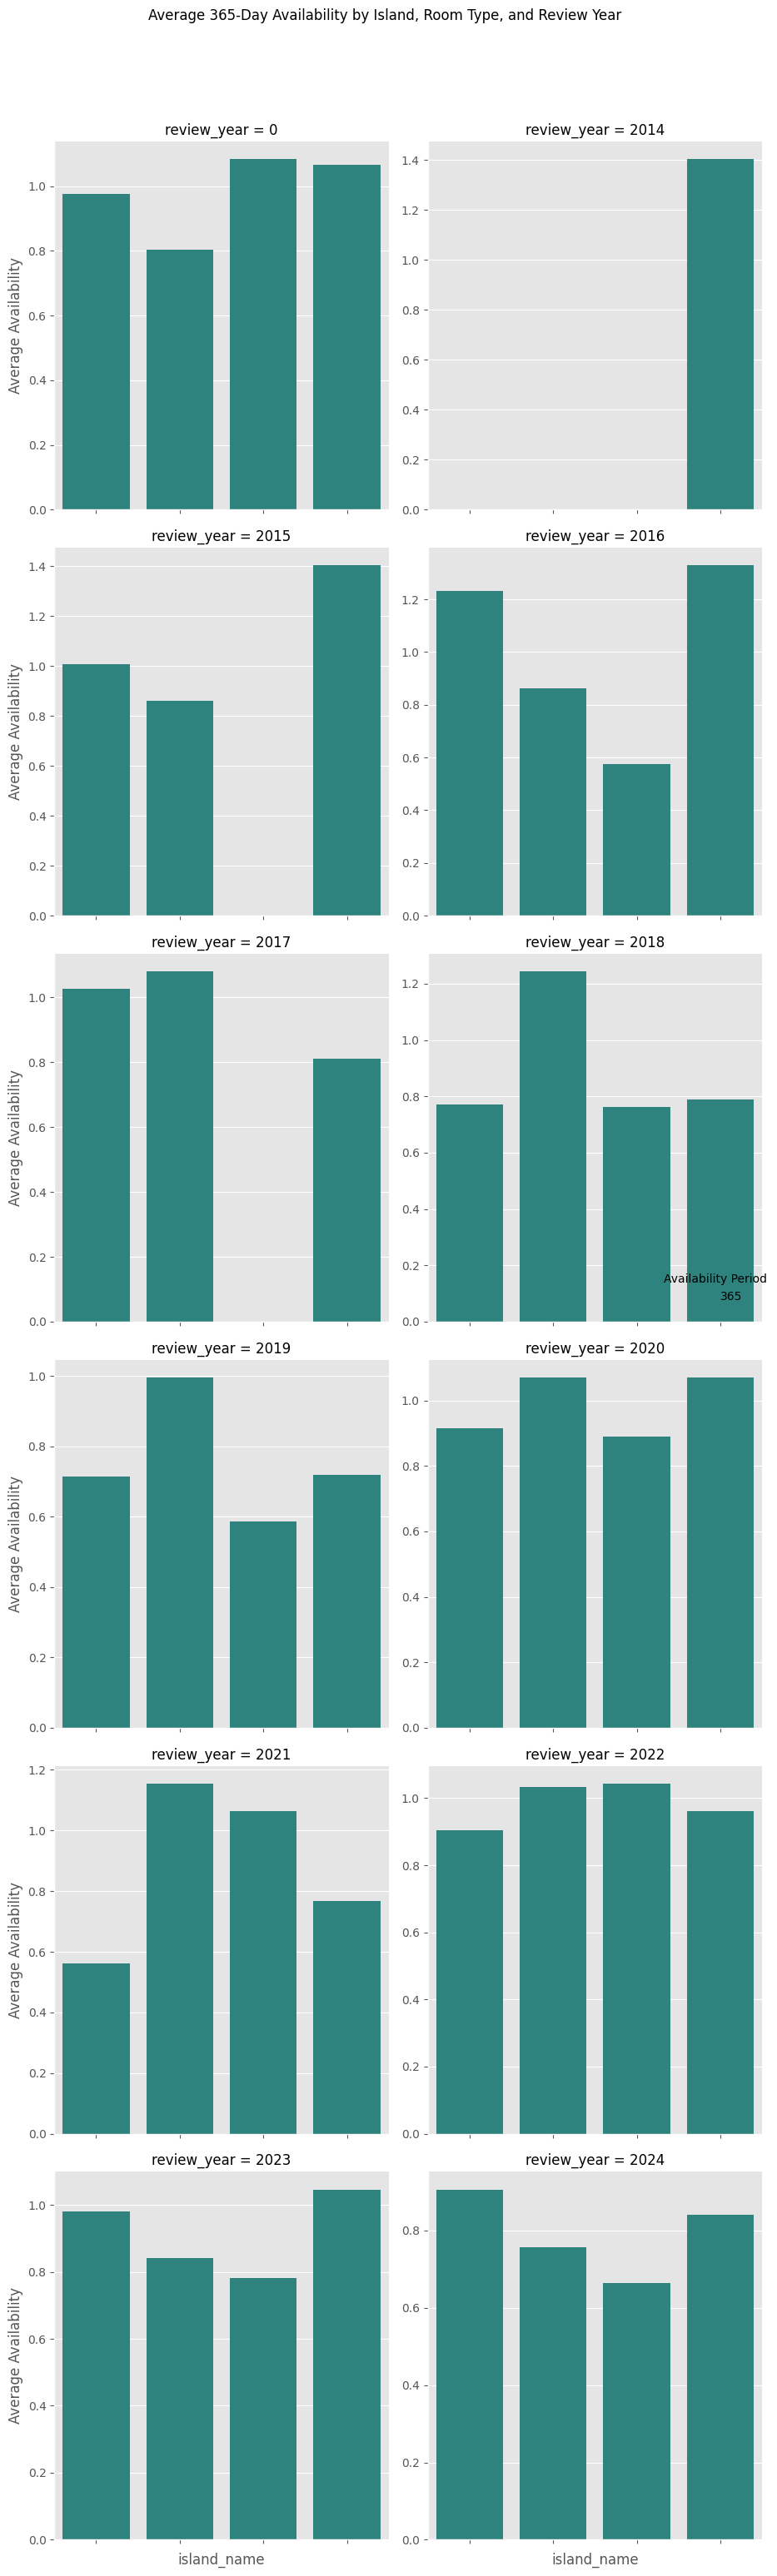

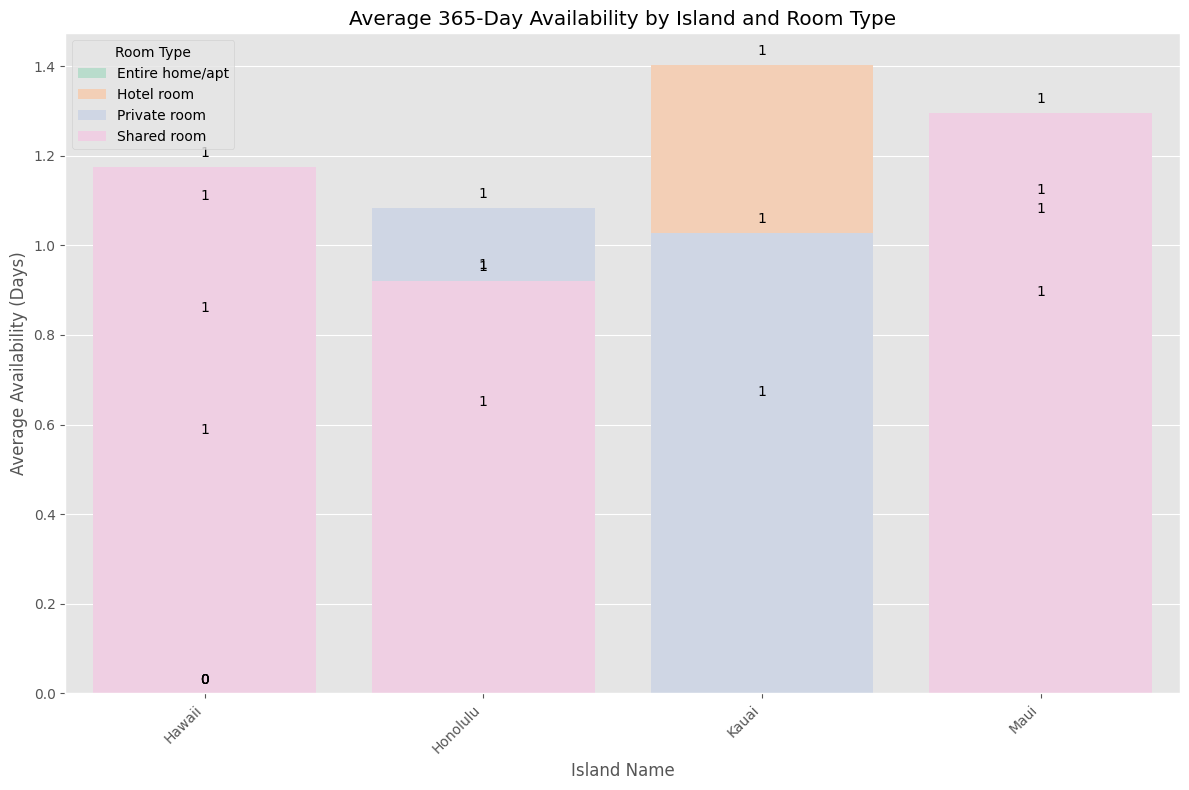

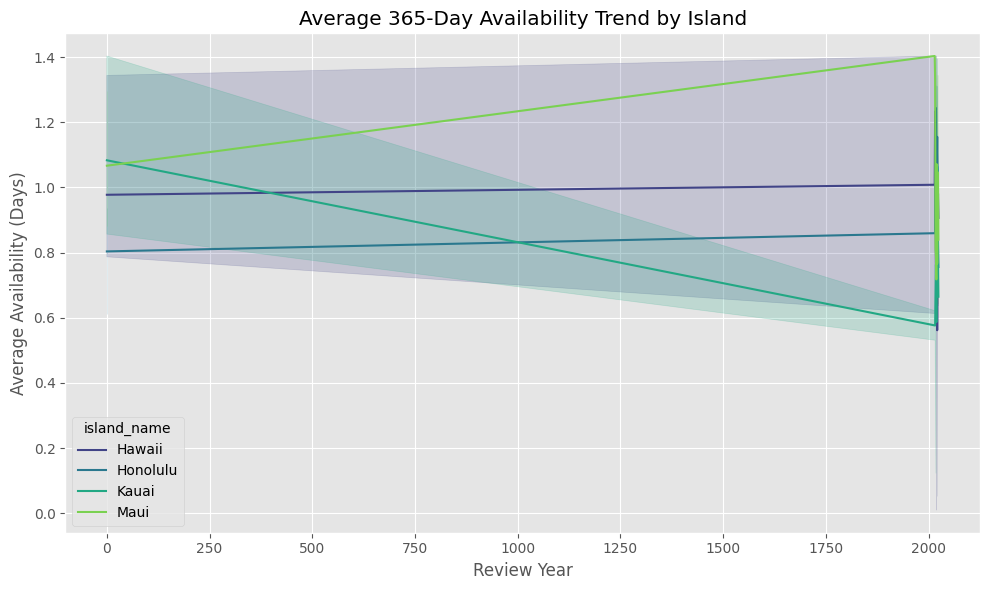

In [30]:
avg_availability_yr = df_data.groupby(['island_name', 'room_type', 'review_year'])[['availability_365']].mean().reset_index()

avg_availability_yr = avg_availability_yr.rename(columns={

    'availability_365': 'Avg_365'
})

melted_df_y = avg_availability_yr.melt(
    id_vars=['island_name', 'room_type', 'review_year'],
    value_vars=['Avg_365'],
    var_name='Availability Period',
    value_name='Average Availability')

# Replace 'Avg_' prefix in 'Availability Period' for better readability
melted_df_y['Availability Period'] = melted_df_y['Availability Period'].str.replace('Avg_', '')

# Create the grouped bar chart with a facet for review_year
g = sns.catplot(
    x='island_name',
    y='Average Availability',
    hue='Availability Period',
    col='review_year',
    data=melted_df_y,
    kind='bar',
    palette='viridis',
    ci=None,
    height=5,
    aspect=0.8,
    col_wrap=2, # 3 columns per row
    sharey = False)  # allow y-axis scales to vary
g.set_xticklabels(rotation=45, ha='right')
g.fig.suptitle('Average 365-Day Availability by Island, Room Type, and Review Year', y=1.03)

plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 8))
sns.barplot(x='island_name',
            y='Average Availability',
            hue='room_type', # Group by room type
            data=melted_df_y[melted_df_y['Availability Period'] == '365'], # Filter for Avg_365
            palette='Pastel2',
            ci=None,
            dodge=False) # Stack bars
plt.title('Average 365-Day Availability by Island and Room Type')
plt.xlabel('Island Name')
plt.ylabel('Average Availability (Days)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Room Type')

# Add annotations (optional)
for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_height():.0f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout()
plt.show()


#Line Chart
plt.figure(figsize=(10, 6))
sns.lineplot(x='review_year',
             y='Average Availability',
             hue='island_name',
             data=melted_df_y[melted_df_y['Availability Period'] == '365'], # Filter for Avg_365
             palette='viridis')
plt.title('Average 365-Day Availability Trend by Island')
plt.xlabel('Review Year')
plt.ylabel('Average Availability (Days)')
plt.tight_layout()
plt.show()

In [31]:
# NA data in reviews_per_month is because there is no last_review data, suggesting there is no reviews at all
# therefore, a reasonable solution is to fill NA data with 0
# fill NA data with 0 in reviews_per_month column

df_data['reviews_per_month'] = df_data['reviews_per_month'].fillna(0)

In [32]:
# after data cleaning, check the basic information about the dataset

df_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18379 entries, 0 to 34003
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              18379 non-null  int64         
 1   name                            18379 non-null  object        
 2   host_id                         18379 non-null  int64         
 3   host_name                       18379 non-null  object        
 4   neighbourhood_cleansed          18379 non-null  object        
 5   island_name                     18379 non-null  object        
 6   latitude                        18379 non-null  float64       
 7   longitude                       18379 non-null  float64       
 8   room_type                       18379 non-null  object        
 9   property_type                   18379 non-null  object        
 10  price                           18379 non-null  float64       
 11  minimum

In [33]:
# Convert 'last_review' to only date
df_data['last_review'] = df_data['last_review'].dt.date

# after data cleaning, check the count, mean, std, min, max, 25%, 50%, and 75% percentile of each attribute
df_data.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,bedrooms,bathrooms,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,availability_30,availability_60,availability_90,availability_365,review_year
count,18379.00,18379.00,18379.00,18379.00,18379.00,18379.00,18379.00,18379.00,18372.00,18379.00,...,18379.00,18379.00,18379.00,18379.00,18379.00,18379.00,18379.00,18379.00,18379.00,18379.00
mean,382966844384466688.00,160590515.29,20.88,-157.16,390.01,-0.02,0.03,-0.00,0.02,0.03,...,4.84,4.82,4.86,4.65,0.12,0.23,0.32,0.40,0.78,1628.67
std,432458790613405312.00,161966242.30,0.81,1.27,538.48,0.93,1.02,0.85,0.99,1.01,...,0.26,0.29,0.21,0.34,1.12,0.94,0.86,0.81,0.41,801.90
min,5387.00,908.00,18.92,-159.71,20.00,-0.27,-0.52,-0.86,-1.40,-1.78,...,1.00,1.00,1.00,1.00,-0.67,-1.11,-1.34,-1.50,0.00,0.00
25%,32338956.00,37839136.00,20.67,-157.84,165.00,-0.27,-0.51,-0.59,-0.52,-0.69,...,4.84,4.82,4.85,4.60,-0.66,-0.52,-0.34,-0.23,0.44,2022.00
50%,52961741.00,103121608.00,20.96,-156.69,255.00,-0.23,-0.36,-0.10,-0.52,-0.69,...,4.88,4.87,4.88,4.68,-0.49,0.07,0.30,0.42,0.79,2024.00
75%,802152431879614464.00,239397319.00,21.29,-156.01,422.00,-0.16,0.10,0.12,0.35,0.39,...,5.00,5.00,4.99,4.83,0.67,0.95,1.05,1.11,1.14,2024.00
max,1117280561441691520.00,567758501.00,22.23,-154.84,17850.00,13.09,16.27,15.54,10.87,11.25,...,5.00,5.00,5.00,5.00,3.51,1.84,1.65,1.59,1.40,2024.00


In [34]:
# after data cleaning, check the missing values in the dataset

df_data.isnull().sum()

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_cleansed,0
island_name,0
latitude,0
longitude,0
room_type,0
property_type,0




# *Exploring **differences** between neighborhoods*






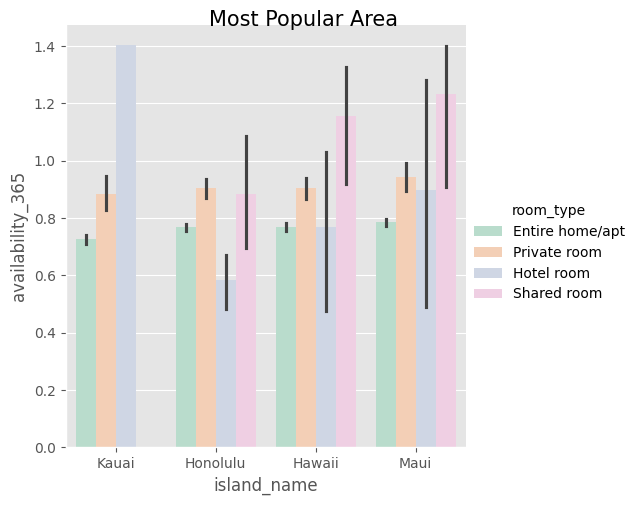

In [35]:
# Availability according to different room_type in different areas

fig = sns.catplot(x='island_name',y='availability_365', data=df_data, kind='bar',hue='room_type',palette='Pastel2')
fig.fig.suptitle('Most Popular Area',fontsize=15,y=1)
fig.savefig('popular_neighborhood.png', bbox_inches = 'tight')

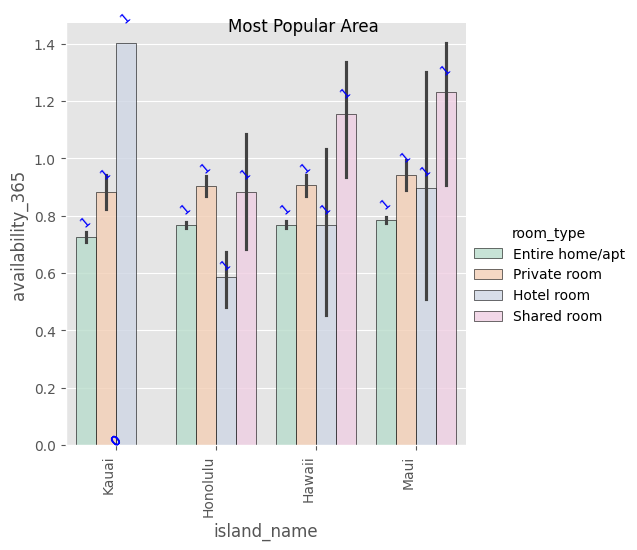

In [36]:
# Availability according to different room_type in different areas
fig = sns.catplot(x='island_name', y='availability_365', data=df_data, kind = 'bar', hue='room_type', palette='Pastel2', edgecolor = 'black', linewidth = 0.5 , alpha = 0.8)
fig.fig.suptitle('Most Popular Area', ha = 'center', fontsize=12)

# Get the axes object
ax = fig.ax

# Iterate through each bar and add annotations
for bar in ax.patches:
    height = bar.get_height()
    label_text = f"{height:.0f}"  # Format the label text
    label_x = bar.get_x() + bar.get_width() / 2  # Center the label horizontally
    label_y = height + (height*0.05)  # Adjust the vertical position of the label
    ax.text(label_x, label_y, label_text, ha='center', rotation = 40, fontsize=10, color='blue')
    plt.xticks(rotation=90, ha='right')

fig.savefig('popular_neighborhood.png', bbox_inches='tight')
plt.show()

# *Average Room Prices by Neighborhood*

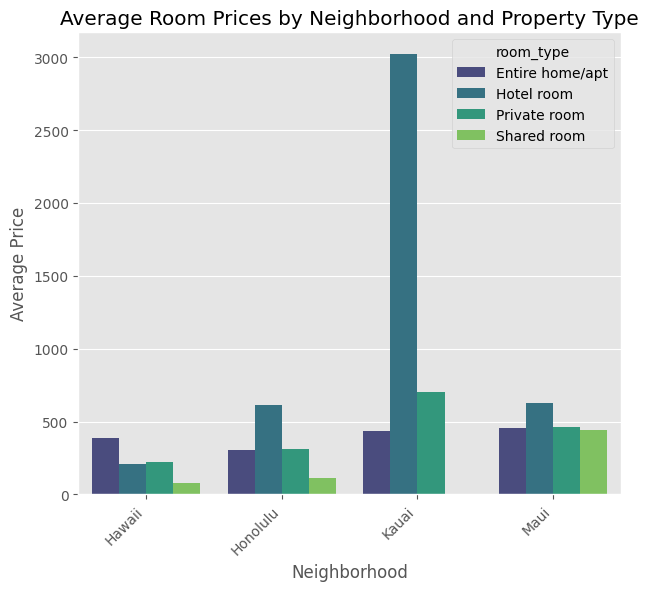

In [37]:


# Calculate average prices for each neighborhood and room type
avg_prices = df_data.groupby(['island_name', 'room_type'])['price'].mean().reset_index()

plt.figure(figsize=(7, 6))  # Adjust figure size if needed
sns.barplot(x='island_name', y='price', hue='room_type', data=avg_prices, palette='viridis')
plt.title('Average Room Prices by Neighborhood and Property Type')
plt.xlabel('Neighborhood')
plt.ylabel('Average Price')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for readability


plt.show()

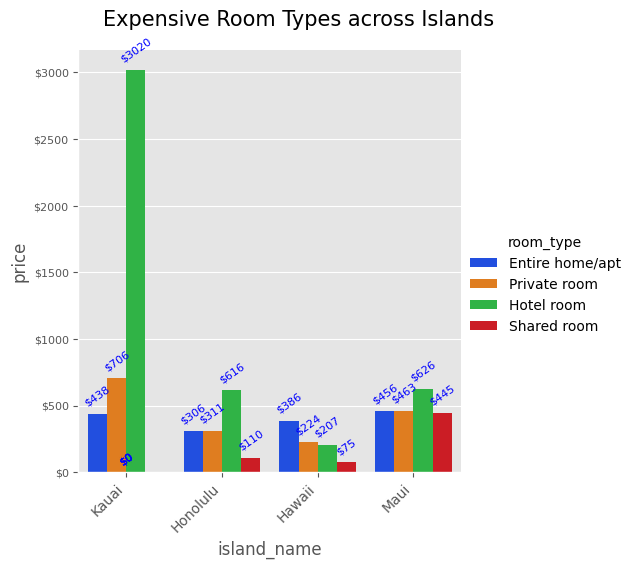

In [38]:
# Price according to different room_type in different areas
fig2 = sns.catplot(x='island_name',y='price',data=df_data,kind='bar',hue='room_type',palette='bright', ci=None)
fig2.fig.suptitle('Expensive Room Types across Islands',fontsize=15,y=1.05)


# Calculate y-axis limits based on price data
ax = fig2.ax
y_min = df_data['price'].min()
y_max = df_data['price'].max()
y_range = y_max - y_min
ax.set_ylim(auto=True)

for bar in ax.patches:
    height = bar.get_height()
    label_text = f"${height:.0f}"

    # Get the x and y coordinates for the label
    label_x = bar.get_x() + bar.get_width() / 2
    label_y = height + 40  # Adjust the vertical position as needed

    # Add the text label
    ax.text(label_x, label_y, label_text, ha='center', va='bottom', fontsize=8, rotation=35, color='blue')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(fontsize=8)
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:.0f}'))


fig2.savefig('price_area.png' )

In [39]:
#extracting year from review dates to filter data.
df_data['last_review'] = pd.to_datetime(df_data['last_review'])
df_data['review_year'] = df_data['last_review'].apply(lambda last_review:last_review.year)
df_data['review_year'] = df_data['review_year'].fillna(0)
df_data['review_year'] = df_data.review_year.astype(int)
df_data = pd.concat([df_data[(df_data['availability_365']==0) & (df_data['review_year']==2019)],df_data[df_data['availability_365']>0]])


# **Islands with Most successful Hosts**

island_name
Honolulu    1709
Hawaii      1674
Maui        1349
Kauai        600
Name: host_id, dtype: int64


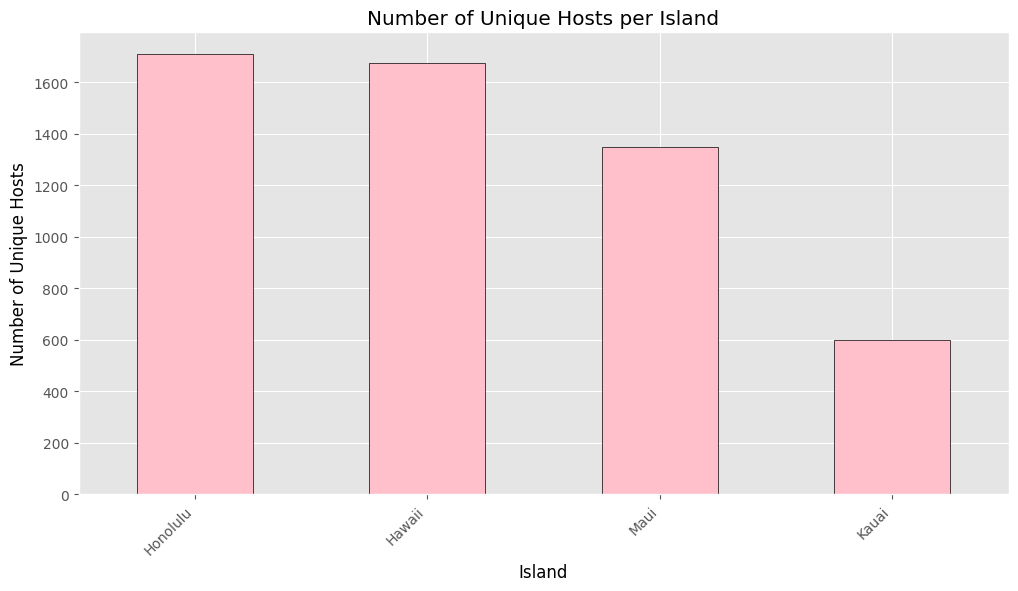

In [40]:
#Unique hosts

# Group the listings by neighbourhood_group_cleansed (regions) and count the unique hosts in each region
host_per_island = df_data.groupby('island_name')['host_id'].nunique().sort_values(ascending=False)

# Display the number of unique hosts for each region (island)
print(host_per_island)

# Plot a bar chart to visualize the number of unique hosts in each region using the defined color palette
plt.figure(figsize=(12, 6))
host_per_island.plot(kind='bar', color='pink', edgecolor='black')
plt.title('Number of Unique Hosts per Island', color='black')
plt.xlabel('Island', color='black')
plt.ylabel('Number of Unique Hosts', color='black')
plt.xticks(rotation=45, ha='right')
plt.show()

In [41]:
# creates 3 new columns in dataframe: revenue, total_revenue, and average revenue

df_data['price'] = df_data['price'].astype(float)
df_data['revenue'] = (365-df_data['availability_365'])*df_data['price']
df_data['total_revenue'] = df_data.groupby('host_id')['revenue'].transform(sum)
df_data['average_revenue'] = df_data['total_revenue']/df_data['calculated_host_listings_count']

df_data.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,bedrooms,...,review_scores_value,calculated_host_listings_count,availability_30,availability_60,availability_90,availability_365,review_year,revenue,total_revenue,average_revenue
count,18379.00,18379.00,18379.00,18379.00,18379.00,18379.00,18379.00,14793,18379.00,18372.00,...,18379.00,18379.00,18379.00,18379.00,18379.00,18379.00,18379.00,18379.00,18379.00,18379.00
mean,382966844384466688.00,160590515.29,20.88,-157.16,390.01,-0.02,0.03,2023-10-15 00:44:52.516730880,-0.00,0.02,...,4.65,0.12,0.23,0.32,0.40,0.78,1628.67,142062.84,12002704.16,3290583.84
min,5387.00,908.00,18.92,-159.71,20.00,-0.27,-0.52,2014-01-06 00:00:00,-0.86,-1.40,...,1.00,-0.67,-1.11,-1.34,-1.50,0.00,0.00,7271.94,10908.16,-1207096398.39
25%,32338956.00,37839136.00,20.67,-157.84,165.00,-0.27,-0.51,2023-10-08 00:00:00,-0.59,-0.52,...,4.60,-0.66,-0.52,-0.34,-0.23,0.44,2022.00,60198.80,208164.75,-1641425.51
50%,52961741.00,103121608.00,20.96,-156.69,255.00,-0.23,-0.36,2024-02-13 00:00:00,-0.10,-0.52,...,4.68,-0.49,0.07,0.30,0.42,0.79,2024.00,92942.46,1847365.55,-183116.78
75%,802152431879614464.00,239397319.00,21.29,-156.01,422.00,-0.16,0.10,2024-03-05 00:00:00,0.12,0.35,...,4.83,0.67,0.95,1.05,1.11,1.14,2024.00,153827.59,11244285.54,15175090.48
max,1117280561441691520.00,567758501.00,22.23,-154.84,17850.00,13.09,16.27,2024-03-22 00:00:00,15.54,10.87,...,5.00,3.51,1.84,1.65,1.59,1.40,2024.00,6499149.29,112740022.73,1165604011.82
std,432458790613405312.00,161966242.30,0.81,1.27,538.48,0.93,1.02,NaN,0.85,0.99,...,0.34,1.12,0.94,0.86,0.81,0.41,801.90,196078.85,22764377.94,120877221.50


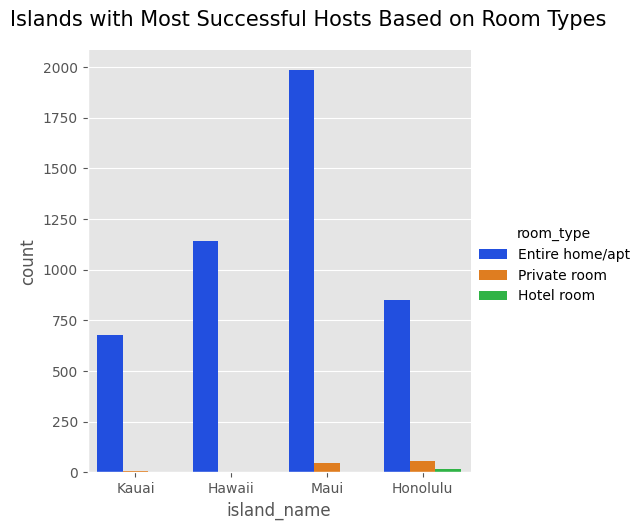

In [42]:
# The count of the 75% percentile hosts according to different room_type in different areas

df2 = df_data[df_data['average_revenue']>=df_data['average_revenue'].quantile(0.75)]
fig3 = sns.catplot(x='island_name',data=df2,hue='room_type',kind='count',palette='bright')
fig3.fig.suptitle('Islands with Most Successful Hosts Based on Room Types',fontsize=15,y=1.05)
fig3.savefig('host.png', bbox_inches = 'tight')

   island_name        room_type  property_type
0       Hawaii  Entire home/apt             34
1       Hawaii       Hotel room              4
2       Hawaii     Private room             25
3       Hawaii      Shared room              5
4     Honolulu  Entire home/apt             25
5     Honolulu       Hotel room              3
6     Honolulu     Private room             18
7     Honolulu      Shared room              5
8        Kauai  Entire home/apt             19
9        Kauai       Hotel room              1
10       Kauai     Private room             10
11        Maui  Entire home/apt             23
12        Maui       Hotel room              2
13        Maui     Private room             14
14        Maui      Shared room              3


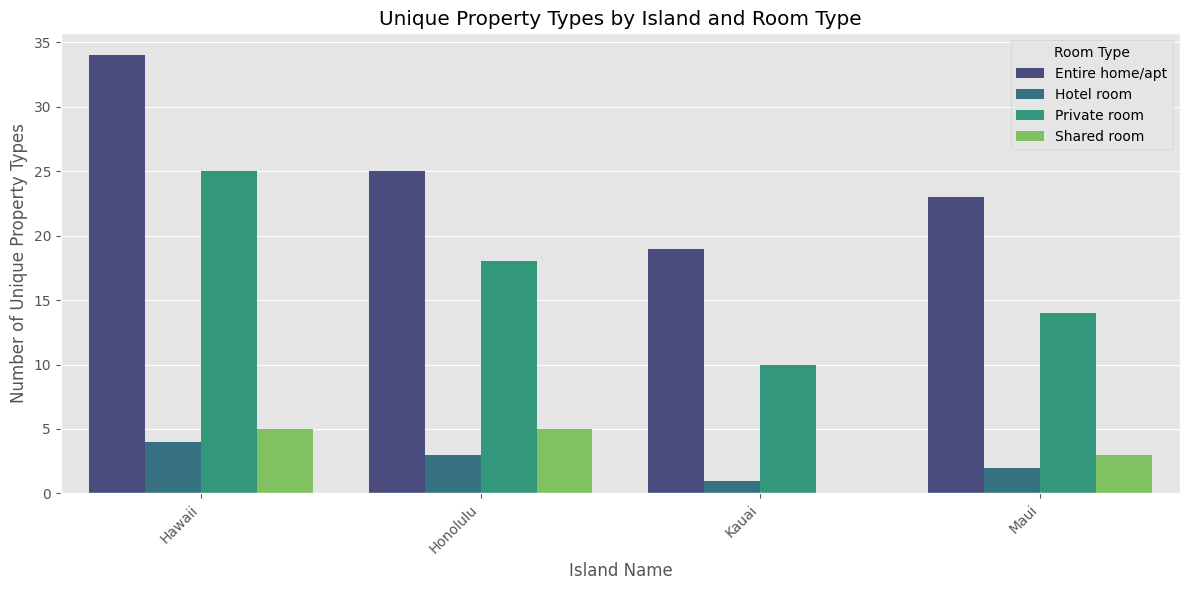

In [43]:
# how prices vary across different neighbourhood groups and room types
# Group data and count unique property types
property_type_counts = df_data.groupby(['island_name', 'room_type'])['property_type'].nunique().reset_index()
print(property_type_counts)

# Create the grouped bar chart
plt.figure(figsize=(12, 6))  # Adjust figure size if needed
sns.barplot(x='island_name', y='property_type', hue='room_type', data=property_type_counts, palette='viridis')
plt.title('Unique Property Types by Island and Room Type')
plt.xlabel('Island Name')
plt.ylabel('Number of Unique Property Types')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for readability
plt.legend(title='Room Type')
plt.tight_layout()
plt.show()

# **Q3. What impacts the list price?**

In [44]:
# Check the types of each variable

df_data.dtypes

,0
id,int64
name,object
host_id,int64
host_name,object
neighbourhood_cleansed,object
island_name,object
latitude,float64
longitude,float64
room_type,object
property_type,object


In [45]:
# Check the numerical variable

df_data.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,bedrooms,...,review_scores_value,calculated_host_listings_count,availability_30,availability_60,availability_90,availability_365,review_year,revenue,total_revenue,average_revenue
count,18379.00,18379.00,18379.00,18379.00,18379.00,18379.00,18379.00,14793,18379.00,18372.00,...,18379.00,18379.00,18379.00,18379.00,18379.00,18379.00,18379.00,18379.00,18379.00,18379.00
mean,382966844384466688.00,160590515.29,20.88,-157.16,390.01,-0.02,0.03,2023-10-15 00:44:52.516730880,-0.00,0.02,...,4.65,0.12,0.23,0.32,0.40,0.78,1628.67,142062.84,12002704.16,3290583.84
min,5387.00,908.00,18.92,-159.71,20.00,-0.27,-0.52,2014-01-06 00:00:00,-0.86,-1.40,...,1.00,-0.67,-1.11,-1.34,-1.50,0.00,0.00,7271.94,10908.16,-1207096398.39
25%,32338956.00,37839136.00,20.67,-157.84,165.00,-0.27,-0.51,2023-10-08 00:00:00,-0.59,-0.52,...,4.60,-0.66,-0.52,-0.34,-0.23,0.44,2022.00,60198.80,208164.75,-1641425.51
50%,52961741.00,103121608.00,20.96,-156.69,255.00,-0.23,-0.36,2024-02-13 00:00:00,-0.10,-0.52,...,4.68,-0.49,0.07,0.30,0.42,0.79,2024.00,92942.46,1847365.55,-183116.78
75%,802152431879614464.00,239397319.00,21.29,-156.01,422.00,-0.16,0.10,2024-03-05 00:00:00,0.12,0.35,...,4.83,0.67,0.95,1.05,1.11,1.14,2024.00,153827.59,11244285.54,15175090.48
max,1117280561441691520.00,567758501.00,22.23,-154.84,17850.00,13.09,16.27,2024-03-22 00:00:00,15.54,10.87,...,5.00,3.51,1.84,1.65,1.59,1.40,2024.00,6499149.29,112740022.73,1165604011.82
std,432458790613405312.00,161966242.30,0.81,1.27,538.48,0.93,1.02,NaN,0.85,0.99,...,0.34,1.12,0.94,0.86,0.81,0.41,801.90,196078.85,22764377.94,120877221.50


In [46]:
# name, host_name, id, host_id are not relevant in the modeling building, so drop them from the dataset
# review_year, revenue, total_revenue, average_revenue are obtained by manipulating the data, they provide redundant information, so drop them from the dataset
# last_review has great missing values and has redundant information with reviews_per_month, so drop it from the dataset
# number_of_reviews provides redundant information with reviews_per_month, so drop it from the dataset
# neighbourhood provides redundant information with neighbourhood_group and it has too many categories, so drop it from the dataset

df_data.columns.to_list()
df_new = df_data.drop(['id', 'host_id', 'host_name','island_name', 'neighbourhood_cleansed', 'last_review','latitude', 'longitude', 'number_of_reviews', 'room_type', 'property_type'], axis=1)

#'revenue','total_revenue','average_revenue'],axis=1)

In [47]:
# check the basic information about the new dataset

df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18379 entries, 0 to 34003
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   name                            18379 non-null  object 
 1   price                           18379 non-null  float64
 2   minimum_nights                  18379 non-null  float64
 3   reviews_per_month               18379 non-null  float64
 4   bedrooms                        18372 non-null  float64
 5   bathrooms                       18379 non-null  float64
 6   beds                            18360 non-null  float64
 7   review_scores_rating            18379 non-null  float64
 8   review_scores_accuracy          18379 non-null  float64
 9   review_scores_cleanliness       18379 non-null  float64
 10  review_scores_checkin           18379 non-null  float64
 11  review_scores_communication     18379 non-null  float64
 12  review_scores_location          18379

       bedrooms  bathrooms
count  18372.00   18379.00
mean       0.77       0.77
std        0.62       0.65
min        0.35       0.15
25%        0.35       0.39
50%        0.52       0.69
75%        1.23       0.69
max       10.87      11.25


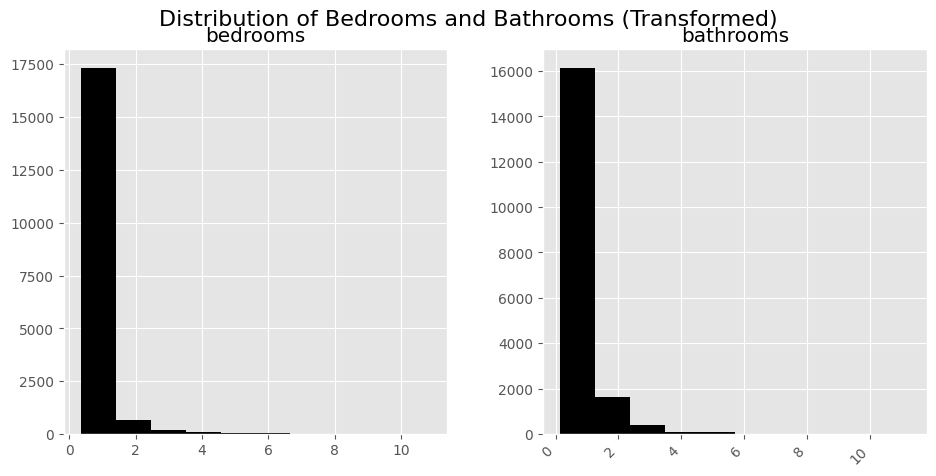

In [48]:

df_new['bedrooms'] = np.abs(df_new['bedrooms'])
df_new['bathrooms'] = np.abs(df_new['bathrooms'])

print(df_new[['bedrooms', 'bathrooms']].describe())

df_new[['bedrooms', 'bathrooms']].hist(color='black', figsize=(10, 5))
plt.tight_layout(pad=3)
plt.subplots_adjust(top=0.9)
plt.suptitle('Distribution of Bedrooms and Bathrooms (Transformed)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.show()

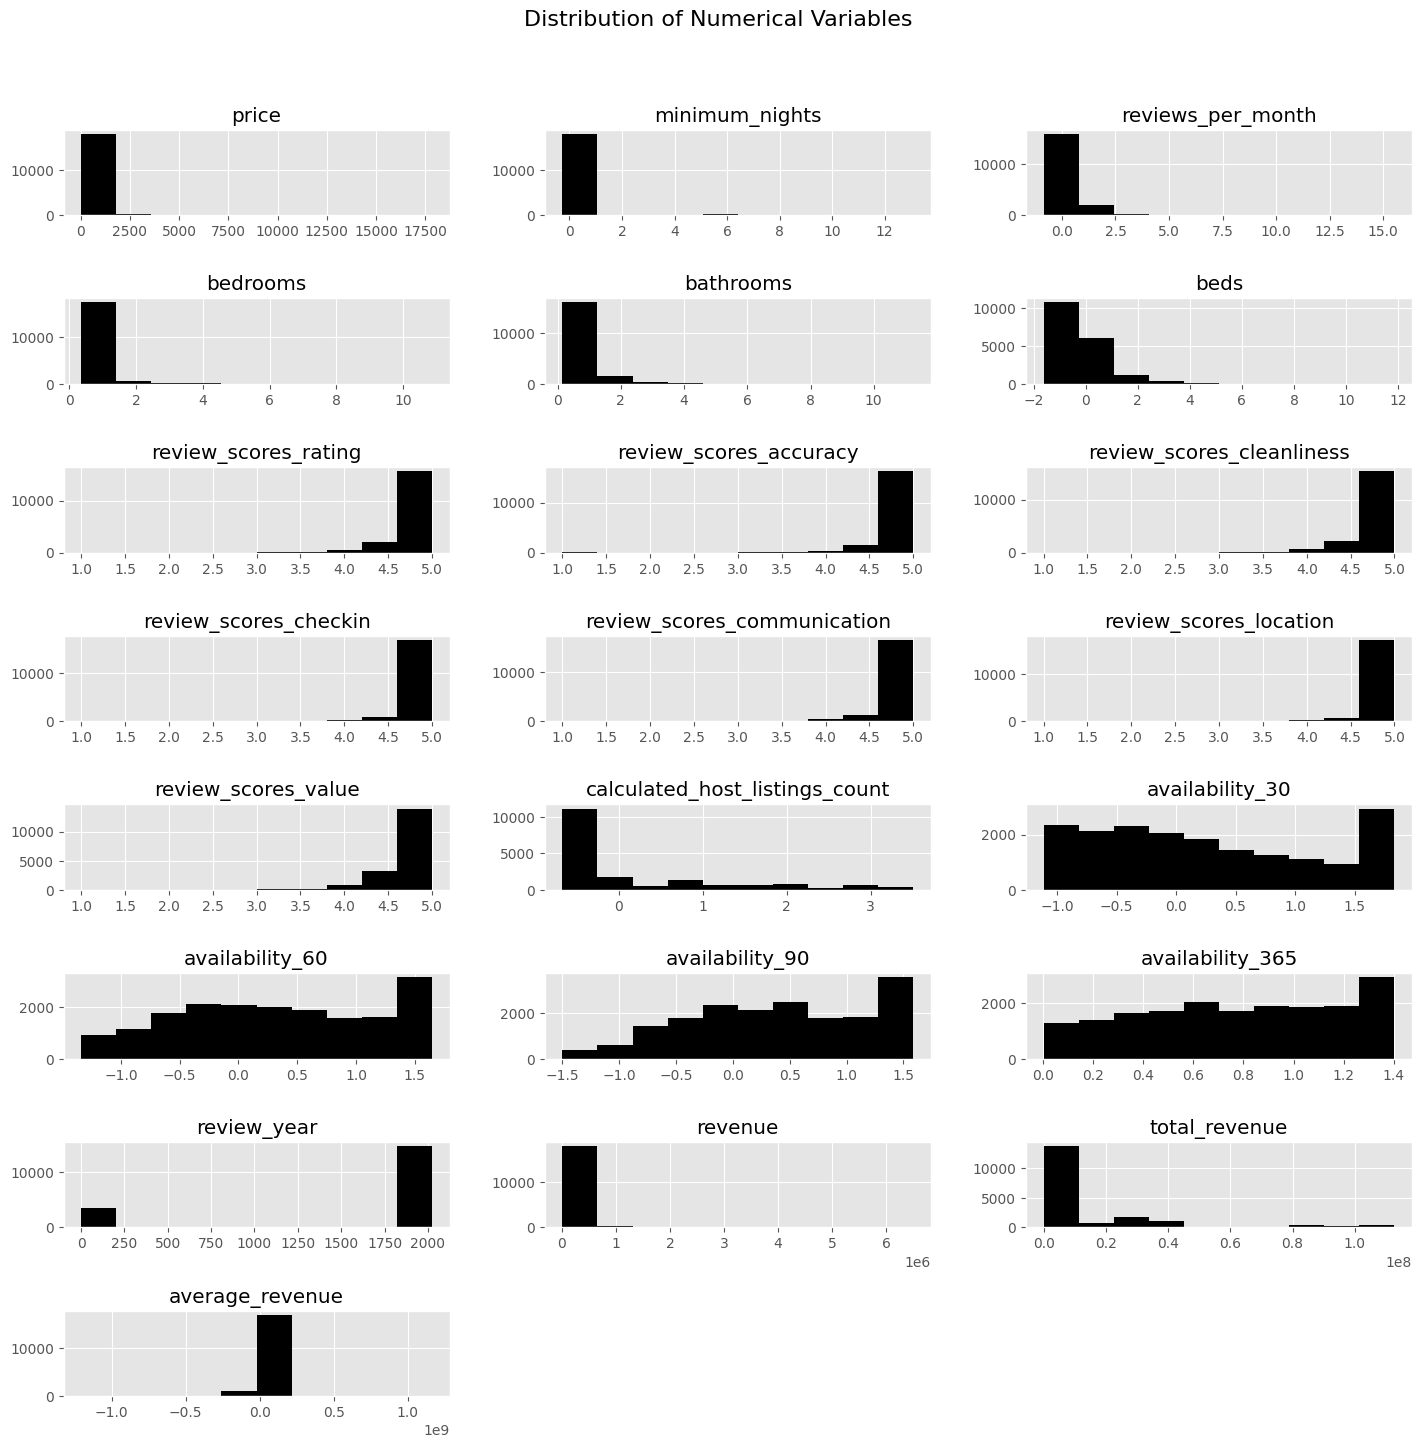

In [49]:
# Check the distribution of each numerical variable

df_new.hist(color='black',layout=(8,3), figsize=(15,15))
plt.tight_layout(pad=3)
plt.subplots_adjust(top=0.9)
plt.suptitle('Distribution of Numerical Variables', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.show()



 Purple shows weak correlation, transitioning to green showing 
 stronger correlation 

 bedrooms, bathrooms, beds, revenue show strong correlation with 
 price as compared to other variables


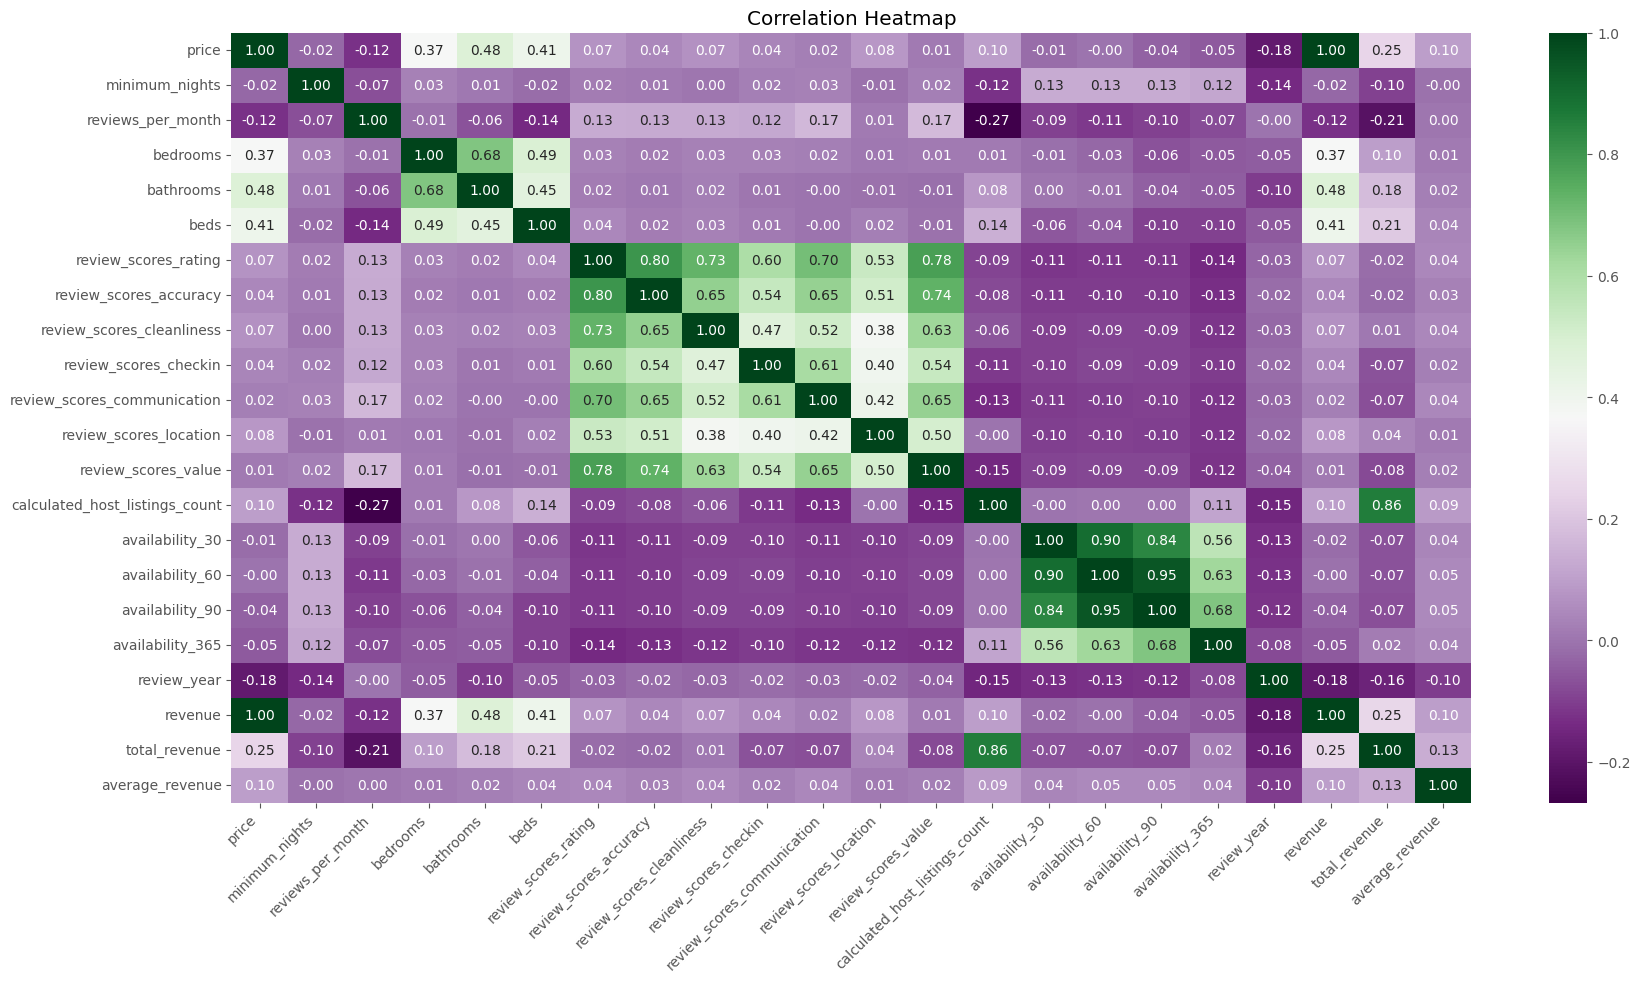


 Revenue shows correlation value of 1, which could potentially cause overfitting of model. Hence we will drop it from the dataframe


In [50]:
# Select only numerical columns before calculating correlations
numerical_df = df_new.select_dtypes(include=['number'])

# Now create the heatmap
plt.figure(figsize=(20, 10))
sns.heatmap(numerical_df.corr(), annot=True, cmap='PRGn', fmt=".2f")
plt.title('Correlation Heatmap')
plt.xticks(rotation=45, ha='right')


print("\n Purple shows weak correlation, transitioning to green showing \n stronger correlation ")

print("\n bedrooms, bathrooms, beds, revenue show strong correlation with \n price as compared to other variables")
plt.show()

print("\n Revenue shows correlation value of 1, which could potentially cause overfitting of model. Hence we will drop it from the dataframe")


In [51]:
df_new = df_new.drop(['revenue'], axis=1)

In [52]:
def create_dummy_df(df, cat_cols, dummy_na):
    for col in cat_cols:
        try:
            df = pd.concat([df.drop(col, axis=1),
                            pd.get_dummies(df[col], prefix=col, prefix_sep='_',
                                           drop_first=False, dummy_na=dummy_na)],
                           axis=1)
        except:
            continue
    return df

# Define cat_cols before using it
cat_cols = ['neighbourhood_group_cleansed', 'room_type'] # Replace with your actual categorical columns

# Apply the function to your existing DataFrame 'df_new'
df_new_with_dummies = create_dummy_df(df_new.copy(), cat_cols, dummy_na=True)

# Check the changes
print(df_new_with_dummies.info())

<class 'pandas.core.frame.DataFrame'>
Index: 18379 entries, 0 to 34003
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   name                            18379 non-null  object 
 1   price                           18379 non-null  float64
 2   minimum_nights                  18379 non-null  float64
 3   reviews_per_month               18379 non-null  float64
 4   bedrooms                        18372 non-null  float64
 5   bathrooms                       18379 non-null  float64
 6   beds                            18360 non-null  float64
 7   review_scores_rating            18379 non-null  float64
 8   review_scores_accuracy          18379 non-null  float64
 9   review_scores_cleanliness       18379 non-null  float64
 10  review_scores_checkin           18379 non-null  float64
 11  review_scores_communication     18379 non-null  float64
 12  review_scores_location          18379

In [53]:
!pip install scikit-learn
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import pandas as pd

def clean_fit_linear_mod(df, response_col, cat_cols, dummy_na, test_size=0.2, rand_state=22):
    '''
    df - a dataframe holding all the variables of interest
    response_col - a string holding the name of the column

    cat_cols - list of strings that are associated with names of the categorical columns

    dummy_na - Bool holding whether you want to dummy NA vals of categorical columns or not

    test_size - a float between [0,1] about what proportion of data should be in the test dataset

    rand_state - an int that is provided as the random state for splitting the data into training and test

    OUTPUT:

    test_score - float - r2 score on the test data

    train_score - float - r2 score on the test data

    lm_model - model object from sklearn

    X_train, X_test, y_train, y_test - output from sklearn train test split used for optimal model

    The function should:
    1. Drop the rows with missing response values
    2. Drop columns with NaN for all the values
    3. Use create_dummy_df to dummy categorical columns
    4. Fill the mean of the column for any missing values
    5. Split data into an X matrix and a response vector y
    6. Create training and test sets of data
    7. Instantiate a LinearRegression model with normalized data
    8. Fit model to the training data
    9. Predict the response for the training data and the test data
    10. Obtain an rsquared value for both the training and test data
    '''

    #Drop the rows with missing response values because when response value is missing, it provides no information to the modeling
    df  = df.dropna(subset=[response_col], axis=0)

    #Drop columns with all NaN values because they are empty columns and cannot be applied to build up model
    df = df.dropna(how='all', axis=1)

    #Dummy categorical variables
    df = create_dummy_df(df, cat_cols, dummy_na)

    # Fill missing numerical values with the mean of the column
    # Iterate over each column in the DataFrame
    for column in df:
        # Check if the column is of numeric type
        if df[column].dtype in ['int64', 'float64']:
            # Calculate the mean of the column, excluding missing values
            mean_value = df[column].mean()
            # Fill missing values in the column with the calculated mean
            df[column].fillna(mean_value, inplace=True)

    #Split into explanatory and response variables
    X = df.drop(response_col, axis=1)
    y = df[response_col]

    # Capture column names before scaling
    X_names = X.columns

    #Split into train and test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=rand_state)

    # Normalize the data using StandardScaler
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)  # Fit and transform on training data
    X_test = scaler.transform(X_test)     # Transform test data using the same scaler

    lm_model = LinearRegression() # Instantiate without 'normalize'
    lm_model.fit(X_train, y_train) #Fit

    #Predict using your model
    y_test_preds = lm_model.predict(X_test)
    y_train_preds = lm_model.predict(X_train)

    #Score using your model
    test_score = r2_score(y_test, y_test_preds)
    train_score = r2_score(y_train, y_train_preds)

    return test_score, train_score, lm_model, X_train, X_test, y_train, y_test

In [54]:
cat_df = df_new.select_dtypes(include=['object'])
cat_cols_lst = cat_df.columns
# all categorical variables have no missing values, so set dummy_na=False
df_new = create_dummy_df(df_new, cat_cols_lst, dummy_na=False)

In [55]:
test_score, train_score, lm_model, X_train, X_test, y_train, y_test = clean_fit_linear_mod(df_new, 'price', cat_cols_lst, dummy_na= False)

In [62]:
print("The rsquared on the training data was {}. The rsquared on the test data was {}.".format(train_score, test_score))

print("\n This implies that model is possibly facing the issue of overfitting and requires reviewing the steps followed for feature selection and pre-processing.")

The rsquared on the training data was 0.9994226191223369. The rsquared on the test data was 0.2709487185511341.

 This implies that model is possibly facing the issue of overfitting and requires reviewing the steps followed for feature selection and pre-processing.


In [68]:
def coef_weights(coefficients, X_train):

    coefs_df = pd.DataFrame()
    # Get column names from original DataFrame (assuming 'df_new1' is available globally)
    coefs_df['est_int'] = df_new.drop('price', axis=1).columns
    coefs_df['coefs'] = coefficients
    coefs_df['abs_coefs'] = np.abs(coefficients)
    coefs_df = coefs_df.sort_values('abs_coefs', ascending=False)
    return coefs_df


coef_df = coef_weights(lm_model.coef_, X_train)
coef_df


,est_int,coefs,abs_coefs
5237,name_Hale 'Ae Kai,136.06,136.06
10057,name_Mauna Lani Oceanfront Two Bedroom Residence,116.71,116.71
10055,name_Mauna Lani Ocean View Two Bedroom Residence,111.25,111.25
5223,name_Haiku House Maui,102.43,102.43
3,bathrooms,99.12,99.12
...,...,...,...
17128,name_Westin Kaanapali Ocean Resort 2BR IslandV...,0.00,0.00
15201,name_Sweet lil Puolani Iki w/2024 Specials!,0.00,0.00
15215,"name_TOP FLOOR, OCEAN VIEW, INCREDIBLE LOCATION",0.00,0.00
15185,name_Sweeping Ocean Views! Lanikea at Waikiki...,0.00,0.00


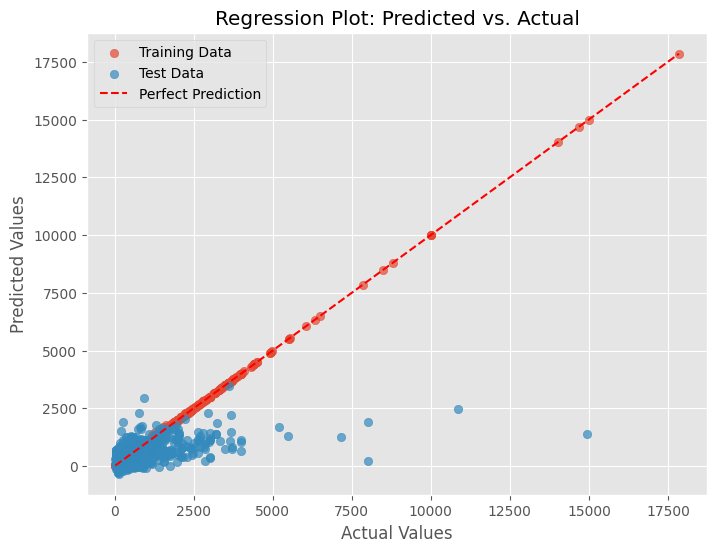

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_train, y_train_pred, label='Training Data', alpha=0.7)  # Training data points
plt.scatter(y_test, y_test_pred, label='Test Data', alpha=0.7)  # Test data points
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], color='red', linestyle='--', label='Perfect Prediction')  # Diagonal line
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Regression Plot: Predicted vs. Actual')
plt.legend()
plt.show()

In [70]:
train_residuals = y_train - y_train_pred
test_residuals = y_test - y_test_pred

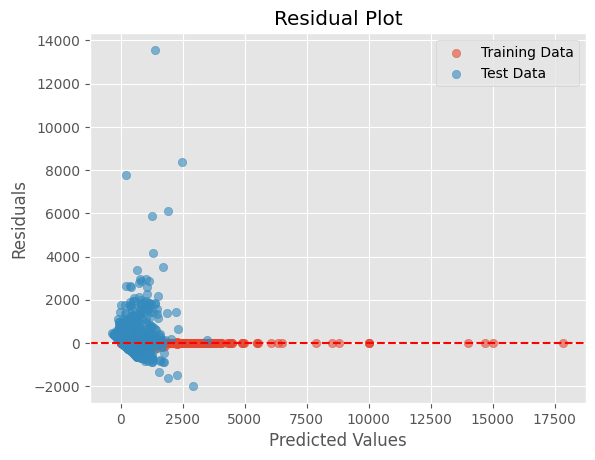

In [71]:
plt.scatter(y_train_pred, train_residuals, label='Training Data', alpha=0.6)
plt.scatter(y_test_pred, test_residuals, label='Test Data', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')  # Horizontal line at 0
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.legend()
plt.show()